## ANN for classification, example 1, mobile phone price class classification

**This version doesn't contain anything extra, just the basic structure needed for ANN classification**

In [23]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

# encoders
from sklearn.preprocessing import LabelEncoder

# classification metrics
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [24]:
# load the data
df = pd.read_csv("mobilepricerangeclass.csv")

In [25]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [26]:
# check the distribution, completely even distribution (uniform)
df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [27]:
# this is technically completely optional
# but it's nicer to study the results when we have actual names for the output
# instead of just 0, 1, 2, 3 etc.

# let's assign actual names for the price classes
# so we have nicer metrics and results later (after training the model)
df['price_range'] = df['price_range'].replace({
    0: "1: Cheap",
    1: "2: Avg-",
    2: "3: Avg+",
    3: "4: Expensive"
})

In [28]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,2: Avg-
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,3: Avg+
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,3: Avg+
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,3: Avg+
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,2: Avg-


## X/y -split

**NOTE! Due to cross entropy, we have to modify the y-variable further! See details below**

In [29]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop("price_range", axis=1)

# have only the target variable here (dependent variable)
y_temp = df['price_range']

# since we are doing classification, we have to process our target values with an encoder
# and convert them into a categorical TensorFlow/Keras -format
le = LabelEncoder()
y_enc = le.fit_transform(y_temp)

# convert the label into matrix form
y = tf.keras.utils.to_categorical(y_enc)

# save the categories into a helper list for later purposes
categories = list(le.classes_)
categories

['1: Cheap', '2: Avg-', '3: Avg+', '4: Expensive']

In [30]:
# compare y_temp and y in order to see how they are different
# y

### train/test/validation -split

In [31]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.35)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

### Create the neural network structure

**NOTE: you can use all the same callback features as in regression: ModelCheckpoint, EarlyStop, ReduceLRONPlateau, Dropout-layers etc...**

In [32]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape

# output layer in classification depends on the amounts of
# unique output options in the target variable
model = keras.Sequential(
    [
        layers.BatchNormalization(input_shape=(variable_amount,)),
        layers.Dense(16, activation="relu", kernel_regularizer=keras.regularizers.l1(l1=0.1)),
        layers.Dense(8, activation="relu"),
        layers.Dense(len(categories), activation="softmax")
    ]
)

# select the optimizer and loss function
# for classification, we use categorical crossentropy this time for loss-function
# we also wish to measure the accuracy of our model in the metrics
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

c:\Users\tuomas.valtanen\deeplearning2026lectures\DeepLearningAutumn2026\.venv\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 588 (2.30 KB)

 Trainable params: 548 (2.14 KB)

 Non-trainable params: 40 (160.00 B)

**Train the next**

In [33]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=300, validation_data=(X_val, y_val))

Epoch 1/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2731 - loss: 7.7121 - val_accuracy: 0.2543 - val_loss: 8.2740
Epoch 2/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2569 - loss: 6.4136 - val_accuracy: 0.2600 - val_loss: 6.0635
Epoch 3/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2692 - loss: 5.3157 - val_accuracy: 0.2429 - val_loss: 4.8710
Epoch 4/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2769 - loss: 4.3795 - val_accuracy: 0.2286 - val_loss: 3.9575
Epoch 5/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2908 - loss: 3.5654 - val_accuracy: 0.2857 - val_loss: 3.1963
Epoch 6/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3215 - loss: 2.8673 - val_accuracy: 0.3029 - val_loss: 2.5507
Epoch 7/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3792 - loss: 2.2756 - val_accuracy: 0.4429 - val_loss: 2.0218
Epoch 8/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4815 - loss: 1.8113 - val_accuracy: 0.5600 - v

### Error and performance metrics

<Axes: >

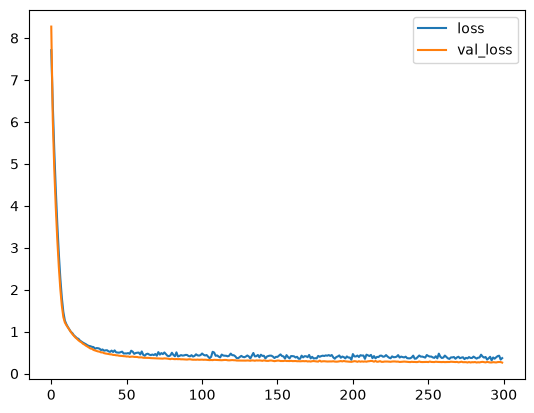

In [34]:
loss_df = pd.DataFrame(model.history.history)
loss_df[['loss', 'val_loss']].plot()

# the model seems to learn fairly well according to loos
# not overfitting, but there's a slight room for improvement

<Axes: >

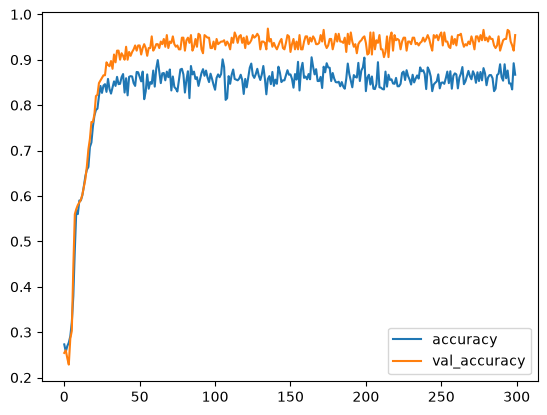

In [35]:
# validation accuracy is fairly high (which is the result from the validation dataset)
# training accuracy is a bit low, but val_accuracy is usually more important to be maximized
# training accuracy being low can imply there's toom for improvement still in the neural network
loss_df[['accuracy', 'val_accuracy']].plot()

In [36]:
# compare the final model loss/evaluation values
# the values should match roughly
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

# in classification we compare the loss and accuracy values

Test data evaluation:
[0.2529999911785126, 0.9457142949104309]

Train data evaluation:
[0.24064970016479492, 0.9753845930099487]


In [37]:
# get predictions and convert with argmax() to get the categories
# instead of RAW probabilites
test_predictions = model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)

# convert also y-test values with argmax
y_test = np.argmax(y_test, axis=1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


<Axes: >

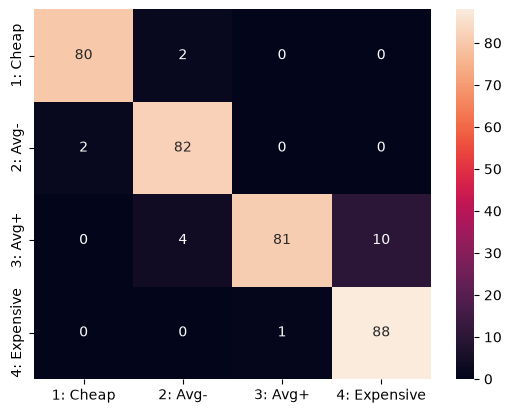

In [38]:
# confusion matrix
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='g',
            xticklabels=categories, yticklabels=categories)

In [39]:
# print the classification report based on true values and predictions
print(classification_report(y_test, test_predictions, target_names=categories))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

    1: Cheap       0.98      0.98      0.98        82
     2: Avg-       0.93      0.98      0.95        84
     3: Avg+       0.99      0.85      0.92        95
4: Expensive       0.90      0.99      0.94        89

    accuracy                           0.95       350
   macro avg       0.95      0.95      0.95       350
weighted avg       0.95      0.95      0.95       350


Model overall accuracy: 94.57%


In [40]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary classification, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multi category classification , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# get ROC-AUC -score
roc_auc_score(y, model.predict(X), multi_class="ovr")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step


0.9989666666666666

### Try the model in practice with new data

In [41]:
X.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='str')

In [42]:
df.head(3)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,2: Avg-
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,3: Avg+
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,3: Avg+


In [43]:
# let's try with some imaginary data
# modify this as needed regarding your own dataset

tester_row = {
    'battery_power': 900, 
    'blue': 0, 
    'clock_speed': 1.2, 
    'dual_sim': 0, 
    'fc': 4, 
    'four_g': 1,
    'int_memory': 64, 
    'm_dep': 0.8, 
    'mobile_wt': 350, 
    'n_cores': 2, 
    'pc': 8, 
    'px_height': 700,
    'px_width': 1400, 
    'ram': 2096, 
    'sc_h': 11, 
    'sc_w': 6, 
    'talk_time': 20, 
    'three_g': 1,
    'touch_screen': 1, 
    'wifi': 1
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])
result = model.predict(tester_row)[0]
result_text = categories[np.argmax(result)]

# switch to decimal representation 
np.set_printoptions(precision=9, suppress=True)

# 0 cheapest, 3 most expensive
print(f"Predicted price range: {result_text}")
print()
print("Probabilities by class:")
print(categories)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted price range: 2: Avg-

Probabilities by class:
['1: Cheap', '2: Avg-', '3: Avg+', '4: Expensive']
[0.010675782 0.93883026  0.050488576 0.000005353]
